# 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
products = pd.read_csv("bigbasket_products.csv")
products.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [2]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [3]:
products.describe()

,index,sale_price,market_price,rating
count,27555.00000,27555.000000,27555.000000,18929.000000
mean,13778.00000,322.514808,382.056664,3.943410
std,7954.58767,486.263116,581.730717,0.739063
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.000000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,12500.000000,12500.000000,5.000000


# 1.1 Data Cleaning

In [4]:
#Drop index column
products = products.drop(columns=["index"])

#Drop product column null value (1 row)
products = products.dropna(subset=["product"])

#fill is with unknown
products["brand"] = products["brand"].fillna("Unknown")

# Handle missing ratings
products['rating'] = products['rating'].fillna(products['rating'].median())

#You have 115 missing descriptions, better to fill it
products["description"] = products["description"].fillna("No description available")

In [5]:
products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27554 entries, 0 to 27554
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product       27554 non-null  object 
 1   category      27554 non-null  object 
 2   sub_category  27554 non-null  object 
 3   brand         27554 non-null  object 
 4   sale_price    27554 non-null  float64
 5   market_price  27554 non-null  float64
 6   type          27554 non-null  object 
 7   rating        27554 non-null  float64
 8   description   27554 non-null  object 
dtypes: float64(3), object(6)
memory usage: 2.1+ MB


In [6]:
# Remove extra spaces
products['category'] = products['category'].str.strip()

products.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


# 1.2 Synthetic Transaction Generation

In [7]:
# Create 5000 customers
customer_ids = [f"CUST_{i}" for i in range(1, 5001)]

# Cities
cities = ["Mumbai", "Delhi", "Bangalore", "Hyderabad", "Chennai", "Pune"]

In [8]:
# Payment modes
payment_modes = ["UPI", "Credit Card", "Debit Card", "COD", "Wallet"]

In [9]:
np.random.seed(42)
random.seed(42)

In [10]:
#Start Empty List
transactions = []                              

for i in range(100000):
    
    product_row = products.sample(1).iloc[0]         # Pick Random Product
    
    quantity = np.random.randint(1, 5)               #Random Quantity
    discount = round(np.random.uniform(0, 0.3), 2)   #Random Discount upto 30%
    
    unit_price = product_row["sale_price"]
    total_amount = quantity * unit_price * (1 - discount)

#Create Order Details  
    transactions.append([
        f"TXN_{i}",
        f"CUST_{random.randint(1,5000)}",
        datetime(2024,1,1) + timedelta(days=random.randint(0,365)),
        product_row["product"],
        quantity,
        unit_price,
        discount,
        total_amount,
        random.choice(["UPI","Credit Card","Debit Card","COD","Wallet"]),
        random.choice(["Mumbai","Delhi","Bangalore","Hyderabad","Chennai","Pune"]),
        random.choice(["App","Web"])
    ])

#Convert to DataFrame
transactions_df = pd.DataFrame(transactions, columns=[
    "transaction_id","customer_id","order_date","product",
    "quantity","unit_price","discount","total_amount",
    "payment_mode","city","channel"
])

#Save to CSV
transactions_df.to_csv("retail_transactions.csv", index=False)

In [11]:
print("✅ 100,000 transactions generated successfully!")

✅ 100,000 transactions generated successfully!


# 1.3 Data Enrichment (Merge Product–Category)

In [12]:
# The transaction dataset contains only product names and sales information.
# To enable category-level business analysis, we merge the product master table
# with the transaction table using the product name as the key.
# This enriches the transaction data with product attributes like category,
# allowing multi-dimensional retail analysis.

transactions_df = transactions_df.merge(
    products[["product", "category"]],
    on="product",
    how="left"
)

In [13]:
transactions_df.to_csv("retail_transactions_final.csv", index=False)

**We have two datasets**  
**1️⃣ Product Master Table**  
Product name  
Price  
Category  
**2️⃣ Transaction Table**  
Customer  
Date  
Payment mode  
Revenue  
City  
Channel  

In [14]:
transactions_df.head()

,transaction_id,customer_id,order_date,product,quantity,unit_price,discount,total_amount,payment_mode,city,channel,category
0,TXN_0,CUST_913,2024-01-13,"Knutzella Bar Bites - Mini, Gluten-free, Vegan",3,112.56,0.08,310.6656,Debit Card,Delhi,App,Gourmet & World Food
1,TXN_1,CUST_1144,2024-02-22,Agent Jack Eau De Toilette For Men,3,419.30,0.18,1031.4780,Wallet,Mumbai,Web,Beauty & Hygiene
2,TXN_2,CUST_261,2024-01-16,"Rice/Akki - Raw, Sona Masoori",4,1169.00,0.11,4161.6400,UPI,Delhi,App,"Foodgrains, Oil & Masala"
3,TXN_3,CUST_4140,2024-11-04,Argan Hair Mask,1,99.00,0.23,76.2300,UPI,Chennai,App,Beauty & Hygiene
4,TXN_4,CUST_4465,2024-08-02,"Confeito Rainbow Vermicelli, Sprinkles",4,128.25,0.25,384.7500,Credit Card,Hyderabad,Web,Gourmet & World Food


In [15]:
transactions_df.info()
transactions_df.describe()
transactions_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147454 entries, 0 to 147453
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   transaction_id  147454 non-null  object        
 1   customer_id     147454 non-null  object        
 2   order_date      147454 non-null  datetime64[ns]
 3   product         147454 non-null  object        
 4   quantity        147454 non-null  int64         
 5   unit_price      147454 non-null  float64       
 6   discount        147454 non-null  float64       
 7   total_amount    147454 non-null  float64       
 8   payment_mode    147454 non-null  object        
 9   city            147454 non-null  object        
 10  channel         147454 non-null  object        
 11  category        147454 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 13.5+ MB


transaction_id    0
customer_id       0
order_date        0
product           0
quantity          0
unit_price        0
discount          0
total_amount      0
payment_mode      0
city              0
channel           0
category          0
dtype: int64

# _____________________________________________________________________________________

# 2. Exploratory Data Analysis (EDA)

# 2.1 Executive KPIs
Objective: To understand the overall performance of the retail platform by calculating key performance indicators.

In [16]:
#Total Revenue

total_revenue = transactions_df["total_amount"].sum()
print(total_revenue)

100691525.39909999


In [17]:
#Total Orders

transactions_df["transaction_id"].nunique()

100000

In [39]:
#Average Order Value (AOV)

transactions_df["total_amount"].sum() / transactions_df["transaction_id"].nunique()

np.float64(1006.9152539909999)

In [19]:
#Unique Customers

transactions_df["customer_id"].nunique()

5000

### Executive Summary Insights

- The platform generated approximately ₹100.7 million in total revenue.
- A total of 100,000 orders were processed across 5,000 customers.
- The average order value (AOV) is ₹1007, indicating moderate basket size.
- On average, each customer placed 20 orders during the period.

# 2.2 Revenue Analysis
### Objective:
To understand how revenue is distributed across key business dimensions such as product categories, cities, sales channels, and payment modes.

This analysis helps identify:
- Which segments are driving the majority of revenue
- Geographic performance trends
- Channel effectiveness
- Customer payment preferences

Understanding these factors is critical for strategic decisions related to inventory planning, marketing focus, and operational optimization.

In [20]:
#Revenue Contribution by Category
#Objective: To identify which product categories contribute the highest revenue and determine key demand drivers.

category_revenue = transactions_df.groupby("category")["total_amount"].sum().sort_values(ascending=False)
category_revenue = category_revenue.round(2)
category_revenue

category
Beauty & Hygiene            32709532.00
Gourmet & World Food        23178831.21
Kitchen, Garden & Pets      17274997.64
Foodgrains, Oil & Masala     8905938.83
Cleaning & Household         6058404.80
Snacks & Branded Foods       4141017.16
Baby Care                    3088348.27
Beverages                    2669304.54
Bakery, Cakes & Dairy        1396878.01
Eggs, Meat & Fish             877694.10
Fruits & Vegetables           390578.83
Name: total_amount, dtype: float64

### Insights:

- "Beauty & Hygiene" is the highest revenue-generating category, contributing significantly more than other categories.
- "Gourmet & World Food" and "Foodgrains, Oil & Masala" are strong secondary revenue drivers.
- "Kitchen, Garden & Pets" and "Foodgrains, Oil & Masala" also contribute significantly to overall revenue.
- Essential and recurring categories such as Cleaning & Household and Snacks show steady contribution.
- Perishable categories such as "Fruits & Vegetables" and "Eggs, Meat & Fish" show comparatively lower revenue contribution.

In [21]:
#Revenue by City
#Objective: To analyze geographic revenue contribution across major metropolitan cities and identify high-performing markets.

transactions_df.groupby("city")["total_amount"].sum().sort_values(ascending=False)

city
Mumbai       1.736421e+07
Chennai      1.693068e+07
Pune         1.685855e+07
Bangalore    1.675087e+07
Hyderabad    1.654665e+07
Delhi        1.624056e+07
Name: total_amount, dtype: float64

### Insights:

- Mumbai generates the highest revenue among all cities (~₹17.36M).
- Chennai and Pune closely follow, indicating strong purchasing activity.
- Revenue distribution across cities is relatively balanced.
- No single city dominates excessively, suggesting diversified demand.

In [22]:
#Channel Contribution
#Objective: To compare revenue contribution across digital channels and identify dominant purchasing platforms.

transactions_df.groupby("channel")["total_amount"].sum()

channel
App    5.054769e+07
Web    5.014383e+07
Name: total_amount, dtype: float64

### Insights:

- Revenue contribution from App and Web channels is nearly equal.
- The App channel slightly outperforms the Web platform.
- The minimal gap indicates balanced platform usage among customers.

In [23]:
#Payment Mode Share
#Objective: To analyze customer payment preferences and understand digital payment adoption trends across transactions.

transactions_df["payment_mode"].value_counts()

payment_mode
Debit Card     29799
COD            29517
UPI            29395
Credit Card    29380
Wallet         29363
Name: count, dtype: int64

### Insights:

- Payment mode distribution is highly balanced across all options.
- Debit Card slightly leads in transaction volume.
- COD continues to remain relevant, indicating sustained trust-based purchasing.
- Digital payment methods (UPI, Cards, Wallets) collectively dominate transactions.

# 2.3 Time-Based Revenue Analysis

In [24]:
#Monthly Revenue Trend
#Objective:To analyze revenue trends over time and identify seasonality or demand fluctuations.

transactions_df["month"] = transactions_df["order_date"].dt.to_period("M")

monthly_revenue = transactions_df.groupby("month")["total_amount"].sum()
monthly_revenue

month
2024-01    8.891513e+06
2024-02    8.252933e+06
2024-03    8.478515e+06
2024-04    8.614487e+06
2024-05    8.325306e+06
2024-06    8.256973e+06
2024-07    8.689080e+06
2024-08    8.556353e+06
2024-09    8.355712e+06
2024-10    8.503015e+06
2024-11    7.733521e+06
2024-12    8.034116e+06
Freq: M, Name: total_amount, dtype: float64

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='month'>

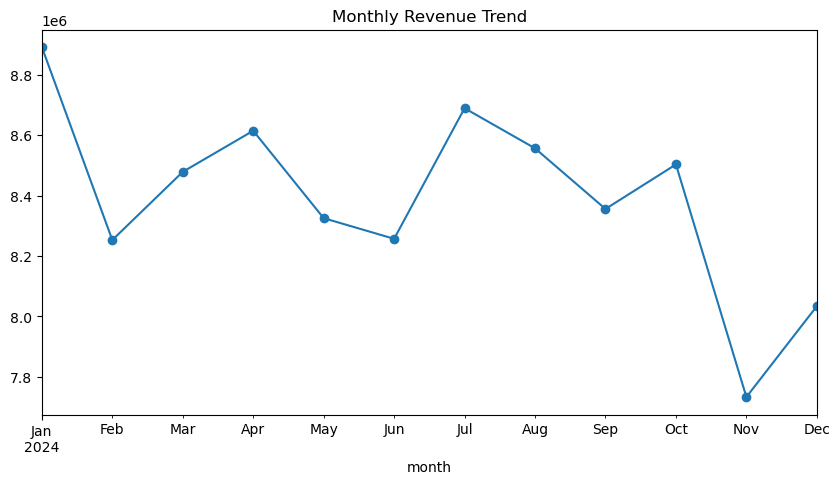

In [25]:
monthly_revenue.plot(figsize=(10,5), marker='o', title="Monthly Revenue Trend")

### Insights:

- Monthly revenue remains relatively stable throughout the year.
- January records the highest revenue (~₹8.89M).
- November shows a noticeable dip compared to other months.
- Overall variation across months is moderate, indicating consistent demand patterns.

In [26]:
#Monthly Order Volume
#Objective: To analyze monthly transaction volume and identify trends in customer purchasing activity over time.

monthly_orders = transactions_df.groupby("month")["transaction_id"].nunique()
monthly_orders

month
2024-01    8368
2024-02    8131
2024-03    8644
2024-04    8030
2024-05    8387
2024-06    8157
2024-07    8515
2024-08    8541
2024-09    8210
2024-10    8382
2024-11    8201
2024-12    8434
Freq: M, Name: transaction_id, dtype: int64

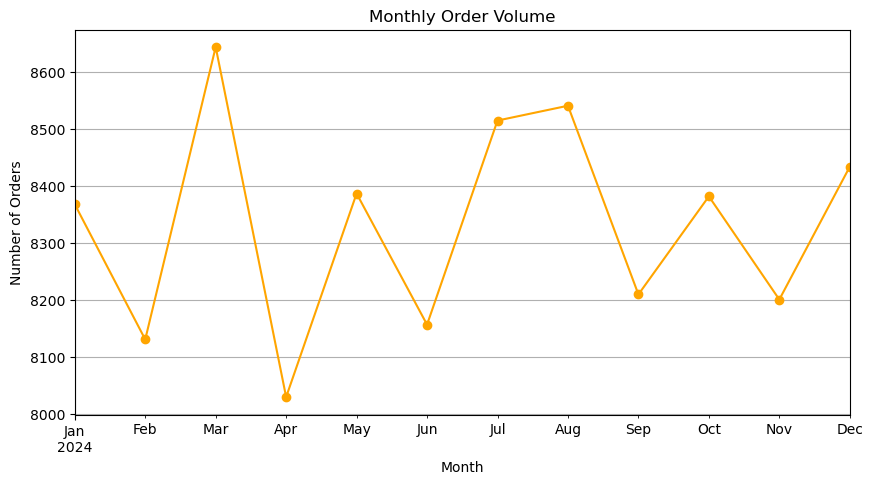

In [27]:
#Monthly Order Volume Line Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_orders.plot(marker='o', color='orange')
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()


### Insights:

- Monthly order volume remains relatively stable throughout the year.
- March records the highest number of orders (~8,644).
- April shows a slight dip (~8,030).
- Overall fluctuation across months is minimal.

# 2.4 Customer Analytics

In [28]:
#RFM Calculation

import datetime as dt

snapshot_date = transactions_df["order_date"].max() + dt.timedelta(days=1)

rfm = transactions_df.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,
    "transaction_id": "count",
    "total_amount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
CUST_1,14,31,18612.1640
CUST_10,36,20,15335.9480
CUST_100,13,26,19983.2988
CUST_1000,40,22,10419.4058
CUST_1001,34,50,17099.2308


In [29]:
rfm.describe()

,Recency,Frequency,Monetary
count,5000.000000,5000.000000,5000.000000
mean,18.563800,29.490800,20138.305080
std,17.437487,9.131144,16047.656422
min,1.000000,7.000000,2138.885200
25%,6.000000,23.000000,12488.745000
50%,13.000000,28.000000,17162.169400
75%,26.000000,35.000000,23113.198200
max,131.000000,88.000000,296242.215400


### RFM Summary Insights

Recency:
- The average customer made a purchase within the last 18 days.
- Most customers are relatively active, indicating strong engagement.

Frequency:
- Customers place approximately 29 orders on average.
- High repeat purchase behavior suggests strong customer retention.

Monetary:
- The average customer spends around ₹20,138 annually.
- A significant gap between mean and maximum spending indicates presence of high-value customers.

### Additional Insight – Customer Inactivity Risk

The median Recency is 13 days, while the maximum Recency extends to 131 days.

This indicates that although most customers are actively purchasing, a subset of customers has not made a purchase in over four months.

These customers may represent an "At Risk" segment and could benefit from targeted re-engagement strategies such as personalized offers or reminder campaigns.


In [30]:
#Create RFM Score Properly
#Create individual scores

rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"], 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [31]:
#Combine into RFM_Score

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [32]:
print(rfm.head())

             Recency  Frequency    Monetary R_score F_score M_score RFM_Score
customer_id                                                                  
CUST_1            14         31  18612.1640       2       3       3       233
CUST_10           36         20  15335.9480       1       1       2       112
CUST_100          13         26  19983.2988       3       2       3       323
CUST_1000         40         22  10419.4058       1       1       1       111
CUST_1001         34         50  17099.2308       1       4       2       142


In [33]:
#Interpret distribution
#Customer Segment Distribution
#Objective: To classify customers based on their purchasing behavior and identify high-value, loyal, and at-risk segments.

rfm["Segment"] = rfm["RFM_Score"].apply(
    lambda x: "Champions" if x == "444"
    else "Loyal" if x[1] == "4"
    else "At Risk" if x[0] == "1"
    else "Regular"
)

rfm["Segment"].value_counts()

Segment
Regular      2890
At Risk       985
Loyal         913
Champions     212
Name: count, dtype: int64

### Insights:

- The majority of customers (2,890) fall under the "Regular" segment, indicating a stable but moderately engaged customer base.
- 913 customers are classified as "Loyal", demonstrating strong repeat purchase behavior.
- 212 customers are identified as "Champions", representing the highest value segment.
- 985 customers are categorized as "At Risk", indicating potential churn risk.


**Approximately 22% of customers (Champions + Loyal) represent high-engagement segments, while nearly 20% show churn risk. This highlights the importance of retention-focused strategies.**

# _____________________________________________________________________________________

# 3. Connecting Python script to MySQL

##  Objective:
To demonstrate structured data querying skills by exporting the dataset into a SQL database and running business queries.

In [34]:
pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [35]:
from sqlalchemy import create_engine
import urllib.parse
import pandas as pd
# MySQL connection
username = "root"
password = "Rishav@sql"
host = "localhost"
port = "3306"
database = "retail_project"
encoded_password = urllib.parse.quote_plus(password)

engine = create_engine(f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "retail_transactions"   # choose any table name
transactions_df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM retail_transactions LIMIT 5;", engine)

,transaction_id,customer_id,order_date,product,quantity,unit_price,discount,total_amount,payment_mode,city,channel,category,month
0,TXN_0,CUST_913,2024-01-13,"Knutzella Bar Bites - Mini, Gluten-free, Vegan",3,112.56,0.08,310.6656,Debit Card,Delhi,App,Gourmet & World Food,2024-01
1,TXN_1,CUST_1144,2024-02-22,Agent Jack Eau De Toilette For Men,3,419.30,0.18,1031.4780,Wallet,Mumbai,Web,Beauty & Hygiene,2024-02
2,TXN_2,CUST_261,2024-01-16,"Rice/Akki - Raw, Sona Masoori",4,1169.00,0.11,4161.6400,UPI,Delhi,App,"Foodgrains, Oil & Masala",2024-01
3,TXN_3,CUST_4140,2024-11-04,Argan Hair Mask,1,99.00,0.23,76.2300,UPI,Chennai,App,Beauty & Hygiene,2024-11
4,TXN_4,CUST_4465,2024-08-02,"Confeito Rainbow Vermicelli, Sprinkles",4,128.25,0.25,384.7500,Credit Card,Hyderabad,Web,Gourmet & World Food,2024-08
